<h1><center>Modelling and Engineering of Nanoscale Materials <br> Exercises session 4: Intro Monte Carlo and molecular dynamics simulations - 2023 </center></h1>
<center>massimo.bocus@ugent.be,  arnout.maet@ugent.be, thomas.nicholas@ugent.be</center>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy 
import random
from ase.units import *

%matplotlib inline

<div class="alert alert-block alert-warning">
<b>Educational Objectives</b> <br> 
    
1. Implement a MC Metropolis algorithm <br>
2. Implement a velocity Verlet algorithm <br>
3. Understand the difference between MC and MD methods    
</div>

## Introduction

For this exercise lesson we will solely use python. To explore the basics of MC and MD algorithms, we will implement the fundamental algorithms and play around with the simulation parameters to understand how they influence the output. This lesson should provide a fundamental understanding of the inner workings of the ever growing collection MC and MD algorithms, and the simulation codes we will use in future lessons.

The 1D potential that will be studied during this exercise will be a potential with a series of different minima, each with their own width and separated from each other by different barrier heights: <br>

$$ V(x) = x^2 + 30 \cdot \left(1+\sin \frac{x^2}{5}\right) $$ 

Start this exercise lesson by plotting this potential between $x=-8.5$ and $x=8.5$.

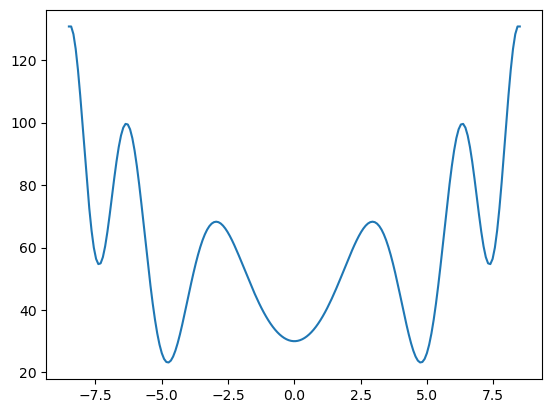

In [32]:
def V(x):
    return x**2 + 30*(1+ np.sin(x**2/5))

x_plot = np.linspace(-8.5, 8.5, 200)
plt.plot(x_plot, V(x_plot))
plt.show()

## Exercise 1: Monte Carlo and the Metropolis algorithm

<div class="alert alert-block alert-warning">
<b>In short:</b> <br>
    1. Construct a Metropolis algorithm <br>
    2. Play around with the parameters to understand their significance <br>
    3. Calculate several statistical quantities
</div>

We start by defining the simulation parameters. If you need to change them, just adapt the code block below and execute it, such that you overwrite the parameters.

In [47]:
# Simulation parameters
from ase.units import _k, _Nav

T = 1000.0            # temperature (unit: K)
kB = _k * _Nav / 1000 # Boltzmann constant (unit: kJ/(mol*K))
num_steps = 3000000   # The number of steps
x0 = -8.0             # Starting point for the metropolis sampling
scale_T = 1.0         # The temperature is multiplied by this factor after each iteration. When set to one, 
                      # the standard metropolis sampling is performed. When set to values below one, 
                      # simulated annealing is performed.

Next, the potential is defined, some data arrays are defined and the actual Metropolis algorithm is implemented. But some code went missing, fix it!

In [48]:
# Potential definition

def pot(x):             # unit: kJ/mol
    return V(x)

In [49]:
# Data containers
x_data = np.zeros(num_steps) # A 1D-array with num_steps elements
e_data = np.zeros(num_steps) # A 1D-array with num_steps elements

In [50]:
# Random number generator
import random

def random_move():
    displacement =  np.random.normal(0, 1.3) # gaussian distribution is a good distribution for a random step
    return displacement
    
print(random_move())

-1.3766273080309324


In [51]:
# The Metropolis algorithm
# Initialization
x = x0
e = pot(x0)

# Perform num_steps steps
for i in range(num_steps):
    # make random move and calculate energy
    x_new = x + random_move()
    e_new = pot(x_new)
    delta_e = e_new - e
    # accepting step conditions
    if delta_e<0:
        x = x_new
        e = e_new
    else:
        R = np.random.uniform(0, 1)
        if np.exp(-delta_e/(kB*T))>=R:
            x = x_new
            e = e_new
    
    # storage
    x_data[i] = x
    e_data[i] = e
    
    # simulated anealing
    T *= scale_T



<div class="alert alert-block alert-success">
<b>Answer the following questions:</b> <br>   
<ol type='a'>
<li> Do MC steps correspond to physical steps? What are the advantages of physical and unphysical steps? </li>
<br>
<li> How does the probability distribution look like (use a histogram)? Use this to plot the free energy profile. Do these profiles correspond with your expectation?  </li>
<br>
<li> What is a measure for the convergence of the simulation? Can this measure be extrapolated to systems containing 100 atoms or more? </li>
<br>
<li> Attempt to finetune the simulation parameters towards better convergence. Which parameters have an effect? </li>
<br>
<li> Calculate the expectation value of $x^2$ using MC and compare this with the theoretical value by way of numerical integration. How do they compare, and can we still compare both for systems with more than 100 atoms?  </li>
<br>
<li> Calculate the standard deviation of $x^2$, and investigate its dependence on the number of steps. Can we use this value to quantify the error of the simulation? </li>
</ol>
</div>

**Add answers here by double-clicking this cell:** <br>


Compare the probability distribution obtained by simulating with the Monte Carlo algorithm
with the analytical Boltzmann distribution.

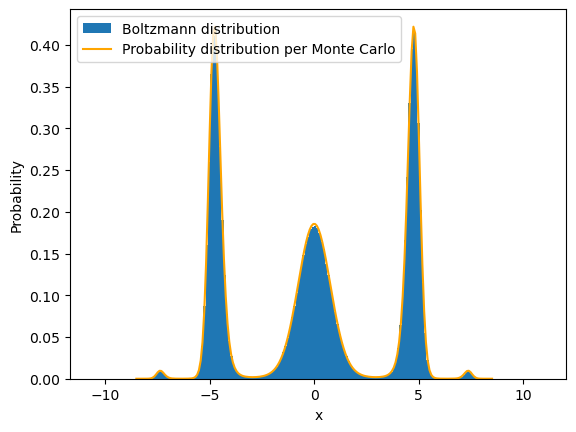

In [59]:
def Boltzmann_function(x):
    return np.exp(-V(x)/(kB*T))

# calculate the boltzmann distribution
Boltzmann_int = scipy.integrate.quad(Boltzmann_function, -8.5, 8.5)[0]
Boltzmann_distribution = lambda x: Boltzmann_function(x)/Boltzmann_int


plt.figure()
plt.hist(x_data, bins=200, density=True, label="Boltzmann distribution")
plt.plot(x_plot, Boltzmann_distribution(x_plot), color="orange", label="Probability distribution per Monte Carlo")
plt.ylabel("Probability")
plt.xlabel("x")
plt.legend()
plt.show()

Now plot the free energy

/tmp/ipykernel_2956965/1027333359.py:4: RuntimeWarning: divide by zero encountered in log
  F = -kB * T * np.log(hist)


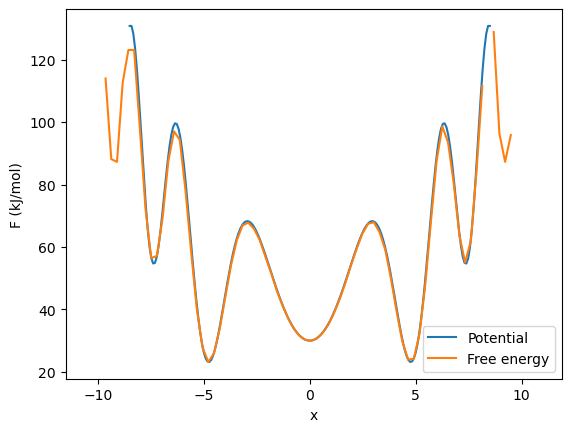

In [56]:
# calculate free energy numerically
hist, bin_edges = np.histogram(x_data, bins=80, density=True)  # get numerical probability distribution
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
F = -kB * T * np.log(hist)
F -= (np.min(F) - np.min(V(x_plot)))


plt.plot(x_plot, V(x_plot), label="Potential")
plt.plot(bin_centers, F, label="Free energy")
plt.xlabel("x")
plt.ylabel("F (kJ/mol)")
plt.legend()
plt.show()

Calculate the expectation value of $x^2$:

In [57]:
x_squared = np.mean(x_data**2)
    
expectation_value_x_squared = lambda x: x**2 * Boltzmann_distribution(x)

theoretical_xsquared = scipy.integrate.quad(expectation_value_x_squared, -8.5, 8.5)[0]/scipy.integrate.quad(Boltzmann_distribution, -8.5, 8.5)[0]
print("Numerical value: %.5f" % x_squared)
print("Theoretical value: %.5f" % theoretical_xsquared)

Numerical value: 14.79237
Theoretical value: 14.69628


Calculate the standard deviation on $x^2$: $<x^2>=<x^4> - <x^2>^2$.

In [61]:
mean_x2 = np.mean(x_data**2)
mean_x4 = np.mean(x_data**4)
sigma_x2 = np.sqrt(mean_x4 - mean_x2**2)
print(f"std(x²) = {sigma_x2:.6f}")

std(x²) = 11.353577


## Exercise 2: Molecular dynamics and the velocity Verlet algorithm

<div class="alert alert-block alert-warning">
<b>In short:</b> <br>
    1. Construct a velocity Verlet algorithm <br>
    2. Play around with the parameters to understand their significance <br>
    3. Try different potentials
</div>

In this exercise, we attempt to discuss the same questions as before to highlight the differences between both methods. As with the MC simulations, we start by defining the simulation parameters. Changing them is again as easy as adapting the code block below and executing it. 

In [106]:
# Simulation parameters (in arbitrary units)

num_steps = 1000000
time_step = 0.02
x0 = 10             # Changed to match plots in the solution
v0 =1.0
mass = 1.0

Next, we define the potential. Since molecular dynamics simulations integrate Newton's equations, the forces have to be calculated as well. As such, implement the gradient of the energy below too. Then, similar to the first exercise, the data arrays are defined and the actual simulation algorithm is implemented. Again, some code is missing and needs fixing.

In [107]:
# Potential and derivatives definition
def compute(x):
    potential = pot(x)
    eps = 0.01
    diff_x = (pot(x+eps/2) - pot(x-eps/2))/eps
    return potential, diff_x

In [108]:
# Data containers
x_data = np.zeros(num_steps) # position as a function of time
v_data = np.zeros(num_steps) # velocity as a function of time
p_data = np.zeros(num_steps) # potential energy as a function of time
k_data = np.zeros(num_steps) # kinetic energy as a function of time

Derive the velocity Verlet algorithm yourself by performing a Taylor expansion (truncating the expression by neglecting 3rd order terms) of the position $x(t+h)$ and the velocity $v(t+h)$ with $h$ a small timestep.

<div class="alert alert-block alert-info">
<b>Tip</b> <br>
    
When writing $x(t+h)$ as a function of ($x(t)$, $v(t)$, $F(x(t))$) and $v(t+h)$ as a function of ($v(t)$, $F(x(t))$, $F(x(t+h))$), the algorithm steps should be apparent.
Remember! You can always write for an infinitesmal timestep $h$: 

$$f'(t) \approx \frac{f(t+h) - f(t)}{h}$$ 
</div>

In [109]:
# Velocity verlet algorithm
# Initialization
x = x0
v = v0
p, g = compute(x0)  # potential energy and gradient
a = -g / mass         # acceleration

# Perform num_steps steps
for i in range(num_steps):
    # the Velocity-Verlet algorithm
    # velocity at half time
    v_half_time = v + time_step /2 * a
    x_next = x + time_step * v_half_time
    # get f at next time
    p_next, grad_next = compute(x_next)
    f_next = - grad_next
    a_next = f_next/mass
    # get new velocity
    v_next = v_half_time + time_step /2 * a_next
    
    # store data
    x_data[i] = x_next
    v_data[i] = v_next
    p_data[i] = p_next
    k_data[i] = 0.5 * mass * v_next**2
    
    # prepare variables for the next iteration
    x = x_next
    v = v_next
    a = a_next

<div class="alert alert-block alert-success">
<b>Answer the following questions:</b> <br>   
<ol type='a'>
<li> Do MD steps correspond to physical steps? </li>
<br>
<li> How does the probability distribution look like (use a histogram)? Does this profile correspond with your expectation?   </li>
<br>
<li> How large can you make the timestep which still provides reasonable results? </li>
<br>
<li> What is the influence of the mass on the simulation? Is the effect comparable to introducing different potentials? </li>
<br>
<li> How can we theoretically determine the maximum timestep for a harmonic potential?</li>
<br>
<li> What happens when you make an error in the energy derivative?</li>
<br>
<li> Calculate the expectation value of $x^2$ using MD and compare this with the MC results. </li>
</ol>
</div>

**Add answers here by double-clicking this cell:** <br>


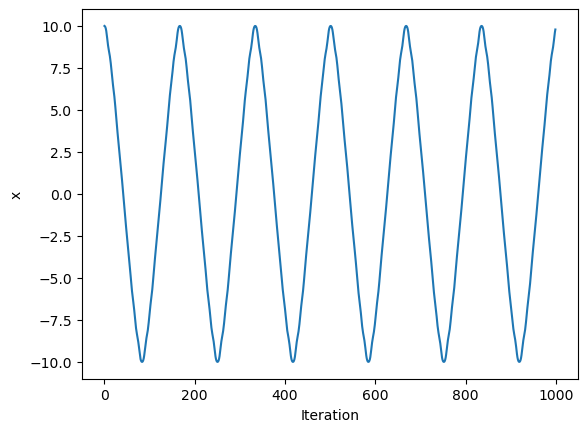

In [110]:
# truncate data to plot
x_truncated = x_data[:1000]
plt.plot(x_truncated)
plt.xlabel("Iteration")
plt.ylabel("x")
plt.show()

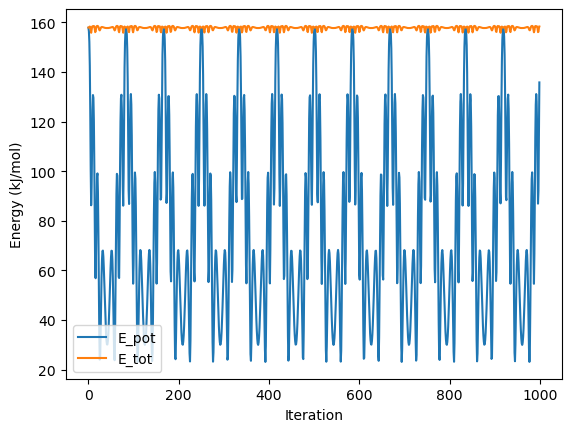

In [111]:
p_truncated = p_data[:1000]
k_truncated = k_data[:1000]
E_truncated = p_truncated + k_truncated
plt.plot(p_truncated, label="E_pot")
plt.plot(E_truncated, label="E_tot")
plt.xlabel("Iteration")
plt.ylabel("Energy (kJ/mol)")
plt.legend()
plt.show()

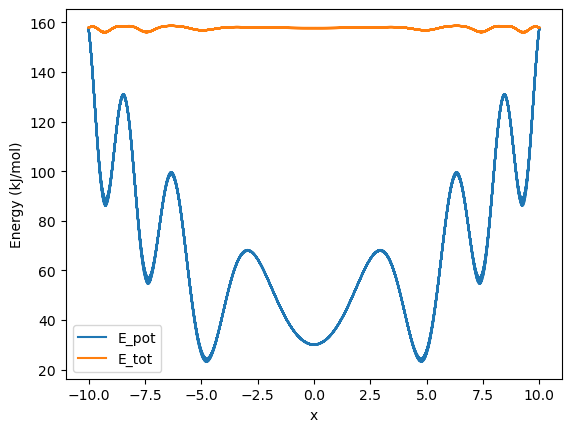

In [112]:
plt.plot(x_truncated, p_truncated, label="E_pot")
plt.plot(x_truncated, E_truncated, label="E_tot")
plt.xlabel("x")
plt.ylabel("Energy (kJ/mol)")
plt.legend()
plt.show()

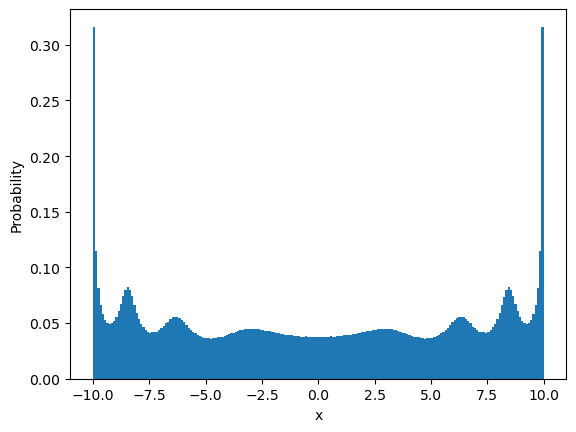

In [115]:
plt.hist(x_data, bins=200, density=True)
plt.xlabel("x")
plt.ylabel("Probability")
plt.show()
# peaks at potential peaks: here the particle is slower
# also: energy conservation

In [118]:
x_squared = np.mean(x_data**2)

E_tot = p + 1/2 * mass * v0**2
# see appendix solutions
def NVE_distribution(x):
    return 1/np.sqrt(E_tot - V(x))
    
expectation_value_x_squared = lambda x: x**2 * NVE_distribution(x)
theoretical_xsquared = scipy.integrate.quad(expectation_value_x_squared, -10, 10)[0]/scipy.integrate.quad(NVE_distribution, -10, 10)[0]
print("Numerical value: %.5f" % x_squared)
print("Theoretical value: %.5f" % theoretical_xsquared)

Numerical value: 42.26549
Theoretical value: 41.21170
